# Road Surface Classification — Vibration Embedding & Clustering

## 1. Install & Imports <a id='1'></a>

In [1]:
import glob
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import random
from pathlib import Path
from tqdm import tqdm
from scipy.fft import fft
import scipy.stats as stats

# Config

In [2]:
CONFIG = {
    'data_dir': Path('../Datasets/Processed_Data/Labeled_Data_Without_GPS'),
    'window_size': 1024,
    'overlap': 0.5,
    'pca_variance_threshold': 0.95
}

# Loading Data

In [3]:
def extract_surface_type_id(path):
    match = re.search(r'SurfaceTypeID_(\d+)', path)
    return int(match.group(1)) if match else None

data_dir = CONFIG['data_dir']
file_paths = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)

files_df = pd.DataFrame({
    "full_path": file_paths,
    "filename": [os.path.basename(p) for p in file_paths],
})

files_df["surface_id"] = files_df["full_path"].apply(extract_surface_type_id)
files_df["device"] = files_df["filename"].apply(lambda x: x.split('_')[3])
files_df = files_df[files_df["device"] == "SamsungGalaxyJ7"]

print(files_df["surface_id"].value_counts())

files_df.head(2)

surface_id
9     150
10    150
8      38
7      36
6      36
2      23
5      22
3      20
4      10
Name: count, dtype: int64


,full_path,filename,surface_id,device
0,../Datasets/Processed_Data/Labeled_Data_Withou...,2019-02-15_SurfaceTypeID_9_SamsungGalaxyJ7_exp...,9,SamsungGalaxyJ7
2,../Datasets/Processed_Data/Labeled_Data_Withou...,2019-02-05_SurfaceTypeID_9_SamsungGalaxyJ7_exp...,9,SamsungGalaxyJ7


# Basic feature extraction

In [5]:

# Feature extraction code goes here (not shown in the provided snippets)

def zero_crossing_rate(signal):
    return ((signal[:-1] * signal[1:]) < 0).sum()

acc_feature_embeddings = []
gyro_feature_embeddings = []

WINDOW_SIZE = CONFIG['window_size']
STEP_SIZE = int(WINDOW_SIZE * (1 - CONFIG['overlap']))

for idx, row in tqdm(files_df.iterrows(), total=len(files_df), desc="Processing files"):
    file_path = row['full_path']
    surface_id = row['surface_id']
    
    data_df = pd.read_csv(file_path)

    # Pad if data is shorter than one window
    if len(data_df) < WINDOW_SIZE:
        pad_size = WINDOW_SIZE - len(data_df)
        pad_df   = pd.concat([data_df] * (pad_size // len(data_df) + 1)).iloc[:pad_size]
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)

    # Pad last incomplete window with edge values
    remainder = len(data_df) % STEP_SIZE
    if remainder != 0:
        pad_size = WINDOW_SIZE - remainder
        pad_df   = data_df.iloc[-pad_size:].copy()
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)


    for start in range(0, len(data_df) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data_df[start:start + WINDOW_SIZE]

        svm = np.sqrt(window['valueX']**2 + window['valueY']**2 + window['valueZ']**2)

        fft_val_x = np.abs(np.fft.fft(window['valueX'].to_numpy()))[:WINDOW_SIZE//2]
        fft_val_y = np.abs(np.fft.fft(window['valueY'].to_numpy()))[:WINDOW_SIZE//2]
        fft_val_z = np.abs(np.fft.fft(window['valueZ'].to_numpy()))[:WINDOW_SIZE//2]

        features = {

            # Time domain features
            'mean_x': window['valueX'].mean(),
            'mean_y': window['valueY'].mean(),
            'mean_z': window['valueZ'].mean(),
            'std_x': window['valueX'].std(),
            'std_y': window['valueY'].std(),
            'std_z': window['valueZ'].std(),
            'var_x': window['valueX'].var(),
            'var_y': window['valueY'].var(),
            'var_z': window['valueZ'].var(),
            'sum_x': window['valueX'].sum(),
            'sum_y': window['valueY'].sum(),
            'sum_z': window['valueZ'].sum(),
            'max_x': window['valueX'].max(),
            'max_y': window['valueY'].max(),
            'max_z': window['valueZ'].max(),
            'min_x': window['valueX'].min(),
            'min_y': window['valueY'].min(),
            'min_z': window['valueZ'].min(),
            'rms_x': np.sqrt(np.mean(window['valueX']**2)),
            'rms_y': np.sqrt(np.mean(window['valueY']**2)),
            'rms_z': np.sqrt(np.mean(window['valueZ']**2)),
            'peak_x': np.max(np.abs(window['valueX'])),
            'peak_y': np.max(np.abs(window['valueY'])),
            'peak_z': np.max(np.abs(window['valueZ'])),
            'crest_factor_x': np.max(np.abs(window['valueX'])) / np.sqrt(np.mean(window['valueX']**2)),
            'crest_factor_y': np.max(np.abs(window['valueY'])) / np.sqrt(np.mean(window['valueY']**2)),
            'crest_factor_z': np.max(np.abs(window['valueZ'])) / np.sqrt(np.mean(window['valueZ']**2)),
            'percentile_95_x': np.percentile(np.abs(window['valueX']), 95),
            'percentile_95_y': np.percentile(np.abs(window['valueY']), 95),
            'percentile_95_z': np.percentile(np.abs(window['valueZ']), 95),
            'percentile_75_x': np.percentile(np.abs(window['valueX']), 75),
            'percentile_75_y': np.percentile(np.abs(window['valueY']), 75),
            'percentile_75_z': np.percentile(np.abs(window['valueZ']), 75),
            'mean_abs_diff_x': np.mean(np.abs(np.diff(window['valueX']))),
            'mean_abs_diff_y': np.mean(np.abs(np.diff(window['valueY']))),
            'mean_abs_diff_z': np.mean(np.abs(np.diff(window['valueZ']))),
            'std_diff_x': np.std(np.diff(window['valueX'])),
            'std_diff_y': np.std(np.diff(window['valueY'])),
            'std_diff_z': np.std(np.diff(window['valueZ'])),
            'energy_x': np.sum(window['valueX']**2),
            'energy_y': np.sum(window['valueY']**2),
            'energy_z': np.sum(window['valueZ']**2),
            
            # Higher-order statistics
            'skew_x': stats.skew(window['valueX']),
            'kurt_x': stats.kurtosis(window['valueX']),
            'skew_y': stats.skew(window['valueY']),
            'kurt_y': stats.kurtosis(window['valueY']),
            'skew_z': stats.skew(window['valueZ']),
            'kurt_z': stats.kurtosis(window['valueZ']),

            # Zero Crossing Rate
            'zcr_x': zero_crossing_rate(window['valueX'].values),
            'zcr_y': zero_crossing_rate(window['valueY'].values),
            'zcr_z': zero_crossing_rate(window['valueZ'].values),

            # Single Vector Magnitude (SVM) features
            'mag_mean': svm.mean(),
            'mag_std': svm.std(),
            'mag_crest_factor': svm.max() / (np.sqrt(np.mean(svm**2)) + 1e-8),
            'mag_kurt': stats.kurtosis(svm),
            'mag_mean_abs_diff': np.mean(np.abs(np.diff(svm))),

            # Axis correlations
            'corr_xy': window['valueX'].corr(window['valueY']),
            'corr_xz': window['valueX'].corr(window['valueZ']),
            'corr_yz': window['valueY'].corr(window['valueZ']),

            # Frequency domain features
            'dominant_freq_x': np.argmax(fft_val_x),
            'spectral_energy_x': np.sum(fft_val_x**2),
            'spectral_entropy_x': -np.sum((fft_val_x/fft_val_x.sum()) * np.log(fft_val_x/fft_val_x.sum() + 1e-10)),
            
            'dominant_freq_y': np.argmax(fft_val_y),
            'spectral_energy_y': np.sum(fft_val_y**2),
            'spectral_entropy_y': -np.sum((fft_val_y/fft_val_y.sum()) * np.log(fft_val_y/fft_val_y.sum() + 1e-10)),
            
            'dominant_freq_z': np.argmax(fft_val_z),
            'spectral_energy_z': np.sum(fft_val_z**2),
            'spectral_entropy_z': -np.sum((fft_val_z/fft_val_z.sum()) * np.log(fft_val_z/fft_val_z.sum() + 1e-10)),

            # Spectral shape features
            'spectral_centroid_x': np.sum(np.arange(len(fft_val_x)) * fft_val_x) / (np.sum(fft_val_x) + 1e-10),
            'spectral_centroid_y': np.sum(np.arange(len(fft_val_y)) * fft_val_y) / (np.sum(fft_val_y) + 1e-10),
            'spectral_centroid_z': np.sum(np.arange(len(fft_val_z)) * fft_val_z) / (np.sum(fft_val_z) + 1e-10),
            
            'spectral_spread_x': np.sqrt(np.sum(((np.arange(len(fft_val_x)) - np.sum(np.arange(len(fft_val_x)) * fft_val_x) / (np.sum(fft_val_x) + 1e-10))**2) * fft_val_x) / (np.sum(fft_val_x) + 1e-10)),
            'spectral_spread_y': np.sqrt(np.sum(((np.arange(len(fft_val_y)) - np.sum(np.arange(len(fft_val_y)) * fft_val_y) / (np.sum(fft_val_y) + 1e-10))**2) * fft_val_y) / (np.sum(fft_val_y) + 1e-10)),
            'spectral_spread_z': np.sqrt(np.sum(((np.arange(len(fft_val_z)) - np.sum(np.arange(len(fft_val_z)) * fft_val_z) / (np.sum(fft_val_z) + 1e-10))**2) * fft_val_z) / (np.sum(fft_val_z) + 1e-10)),
        
            
            'surface_id': surface_id
        }

        if 'accelerometer' in file_path.lower():
            acc_feature_embeddings.append(features)
        elif 'gyroscope' in file_path.lower():
            gyro_feature_embeddings.append(features)

# Clean inf to zeros
acc_feature_embeddings = np.nan_to_num(acc_feature_embeddings, nan=0.0, posinf=0.0, neginf=0.0)
gyro_feature_embeddings = np.nan_to_num(gyro_feature_embeddings, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Extracted features from {len(acc_feature_embeddings)} accelerometer windows and {len(gyro_feature_embeddings)} gyroscope windows.")

Processing files: 100%|██████████| 485/485 [00:15<00:00, 30.83it/s] 

Extracted features from 2775 accelerometer windows and 2744 gyroscope windows.


# L2 Normalization + PCA

In [7]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


def postprocess(embeddings, variance_threshold):
    """
    Apply L2 normalization and PCA to feature embeddings.
    
    Args:
        embeddings: numpy array of shape (n_samples, n_features)
        sensor_name: string name of the sensor for logging
        variance_threshold: cumulative variance threshold for PCA
    
    Returns:
        normalized embeddings, PCA-transformed embeddings, fitted PCA object
    """
    # Remove the last column (surface_id label)
    X = embeddings[:, :-1]
    
    # L2 normalization
    X_norm = normalize(X, norm='l2', axis=1)
    
    # PCA
    pca = PCA(n_components=variance_threshold, svd_solver='full')
    X_pca = pca.fit_transform(X_norm)
    
    print(f"Original dimensions: {X.shape[1]}, "
          f"PCA dimensions: {X_pca.shape[1]}, "
          f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")
    
    return X_norm, X_pca, pca


acc_emb_norm, acc_emb_pca, acc_pca = postprocess(
    np.array([list(d.values()) for d in acc_feature_embeddings]),
    CONFIG['pca_variance_threshold']
)

gyro_emb_norm, gyro_emb_pca, gyro_pca = postprocess(
    np.array([list(d.values()) for d in gyro_feature_embeddings]),
    CONFIG['pca_variance_threshold']
)

Original dimensions: 74, PCA dimensions: 3, Explained variance: 0.9577
Original dimensions: 74, PCA dimensions: 2, Explained variance: 0.9745


In [8]:

n_clusters = len(files_df['surface_id'].unique())

# Clustering

| Method | When to use |
|--------|-------------|
| `kmeans` | Known K, fast, good general baseline |
| `agglomerative` | Best cluster separation, cosine metric |
| `dbscan` | Unknown K, automatically finds transition zones |

In [9]:
## K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# K-Means on accelerometer data
kmeans_acc = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_kmeans_acc = kmeans_acc.fit_predict(acc_emb_pca)

# K-Means on gyroscope data
kmeans_gyro = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_kmeans_gyro = kmeans_gyro.fit_predict(gyro_emb_pca)

print("K-Means Clustering Results:")
print(f"Accelerometer - Silhouette: {silhouette_score(acc_emb_pca, labels_kmeans_acc):.4f}")
print(f"Accelerometer - Davies-Bouldin: {davies_bouldin_score(acc_emb_pca, labels_kmeans_acc):.4f}")
print(f"Accelerometer - Calinski-Harabasz: {calinski_harabasz_score(acc_emb_pca, labels_kmeans_acc):.4f}")
print(f"\nGyroscope - Silhouette: {silhouette_score(gyro_emb_pca, labels_kmeans_gyro):.4f}")
print(f"Gyroscope - Davies-Bouldin: {davies_bouldin_score(gyro_emb_pca, labels_kmeans_gyro):.4f}")
print(f"Gyroscope - Calinski-Harabasz: {calinski_harabasz_score(gyro_emb_pca, labels_kmeans_gyro):.4f}")

K-Means Clustering Results:
Accelerometer - Silhouette: 0.3463
Accelerometer - Davies-Bouldin: 0.9740
Accelerometer - Calinski-Harabasz: 1813.1202

Gyroscope - Silhouette: 0.3430
Gyroscope - Davies-Bouldin: 0.8343
Gyroscope - Calinski-Harabasz: 1850.6130


In [10]:

## Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from sympy import python

# Agglomerative on accelerometer data
agg_acc = AgglomerativeClustering(n_clusters=n_clusters, metric='cosine', linkage='average')
labels_agg_acc = agg_acc.fit_predict(acc_emb_norm)

# Agglomerative on gyroscope data
agg_gyro = AgglomerativeClustering(n_clusters=n_clusters, metric='cosine', linkage='average')
labels_agg_gyro = agg_gyro.fit_predict(gyro_emb_norm)

print("\nAgglomerative Clustering Results:")
print(f"Accelerometer - Silhouette: {silhouette_score(acc_emb_norm, labels_agg_acc, metric='cosine'):.4f}")
print(f"Accelerometer - Davies-Bouldin: {davies_bouldin_score(acc_emb_norm, labels_agg_acc):.4f}")
print(f"Accelerometer - Calinski-Harabasz: {calinski_harabasz_score(acc_emb_norm, labels_agg_acc):.4f}")
print(f"\nGyroscope - Silhouette: {silhouette_score(gyro_emb_norm, labels_agg_gyro, metric='cosine'):.4f}")
print(f"Gyroscope - Davies-Bouldin: {davies_bouldin_score(gyro_emb_norm, labels_agg_gyro):.4f}")
print(f"Gyroscope - Calinski-Harabasz: {calinski_harabasz_score(gyro_emb_norm, labels_agg_gyro):.4f}")


Agglomerative Clustering Results:
Accelerometer - Silhouette: 0.4309
Accelerometer - Davies-Bouldin: 0.8975
Accelerometer - Calinski-Harabasz: 1125.7040

Gyroscope - Silhouette: 0.4195
Gyroscope - Davies-Bouldin: 0.6835
Gyroscope - Calinski-Harabasz: 617.6197


In [11]:
## DBSCAN Clustering

from sklearn.cluster import DBSCAN

# DBSCAN on accelerometer data
dbscan_acc = DBSCAN(eps=0.5, min_samples=10, metric='euclidean')
labels_dbscan_acc = dbscan_acc.fit_predict(acc_emb_pca)

# DBSCAN on gyroscope data
dbscan_gyro = DBSCAN(eps=0.5, min_samples=10, metric='euclidean')
labels_dbscan_gyro = dbscan_gyro.fit_predict(gyro_emb_pca)

n_clusters_acc = len(set(labels_dbscan_acc)) - (1 if -1 in labels_dbscan_acc else 0)
n_noise_acc = list(labels_dbscan_acc).count(-1)

n_clusters_gyro = len(set(labels_dbscan_gyro)) - (1 if -1 in labels_dbscan_gyro else 0)
n_noise_gyro = list(labels_dbscan_gyro).count(-1)

print("\nDBSCAN Clustering Results:")
print(f"Accelerometer - Clusters found: {n_clusters_acc}, Noise points: {n_noise_acc}")
if n_clusters_acc > 1:
    print(f"Accelerometer - Silhouette: {silhouette_score(acc_emb_pca, labels_dbscan_acc):.4f}")
    
print(f"\nGyroscope - Clusters found: {n_clusters_gyro}, Noise points: {n_noise_gyro}")
if n_clusters_gyro > 1:
    print(f"Gyroscope - Silhouette: {silhouette_score(gyro_emb_pca, labels_dbscan_gyro):.4f}")


DBSCAN Clustering Results:
Accelerometer - Clusters found: 1, Noise points: 0

Gyroscope - Clusters found: 1, Noise points: 0


# Evaluate and comparison

In [12]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def evaluate(embeddings, labels, gt_labels=None, metric='euclidean'):
    labels = np.asarray(labels)
    valid = labels != -1  # ignore DBSCAN noise
    lv = labels[valid]
    ev = embeddings[valid]

    if len(np.unique(lv)) < 2:
        return {
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan,
            'ARI': np.nan if gt_labels is not None else None,
            'NMI': np.nan if gt_labels is not None else None,
            'Quality': 'Only 1 cluster'
        }

    out = {
        'Silhouette': silhouette_score(ev, lv, metric=metric),
        'Davies-Bouldin': davies_bouldin_score(ev, lv),
        'Calinski-Harabasz': calinski_harabasz_score(ev, lv),
    }

    if gt_labels is not None:
        gv = np.asarray(gt_labels)[valid]
        out['ARI'] = adjusted_rand_score(gv, lv)
        out['NMI'] = normalized_mutual_info_score(gv, lv)

    s = out['Silhouette']
    out['Quality'] = 'Excellent' if s > 0.6 else 'Good' if s > 0.4 else 'Fair' if s > 0.2 else 'Poor'
    return out

# Ground-truth window labels from extracted feature dicts
acc_gt = np.array([d['surface_id'] for d in acc_feature_embeddings])
gyro_gt = np.array([d['surface_id'] for d in gyro_feature_embeddings])

rows = {
    'ACC_KMeans': evaluate(acc_emb_pca, labels_kmeans_acc, acc_gt, metric='euclidean'),
    'ACC_Agg': evaluate(acc_emb_norm, labels_agg_acc, acc_gt, metric='cosine'),
    'ACC_DBSCAN': evaluate(acc_emb_pca, labels_dbscan_acc, acc_gt, metric='euclidean'),
    'GYRO_KMeans': evaluate(gyro_emb_pca, labels_kmeans_gyro, gyro_gt, metric='euclidean'),
    'GYRO_Agg': evaluate(gyro_emb_norm, labels_agg_gyro, gyro_gt, metric='cosine'),
    'GYRO_DBSCAN': evaluate(gyro_emb_pca, labels_dbscan_gyro, gyro_gt, metric='euclidean'),
}

comp_df = pd.DataFrame(rows).T
print(comp_df.to_string(float_format=lambda x: f"{x:.4f}"))

            Silhouette Davies-Bouldin Calinski-Harabasz    ARI    NMI         Quality
ACC_KMeans      0.3463         0.9740         1813.1202 0.2080 0.3167            Fair
ACC_Agg         0.4309         0.8975         1125.7040 0.2267 0.3476            Good
ACC_DBSCAN         NaN            NaN               NaN    NaN    NaN  Only 1 cluster
GYRO_KMeans     0.3430         0.8343         1850.6130 0.0269 0.1171            Fair
GYRO_Agg        0.4195         0.6835          617.6197 0.0024 0.0902            Good
GYRO_DBSCAN        NaN            NaN               NaN    NaN    NaN  Only 1 cluster


# Visualization

Reducing embeddings to 2D using t-SNE...


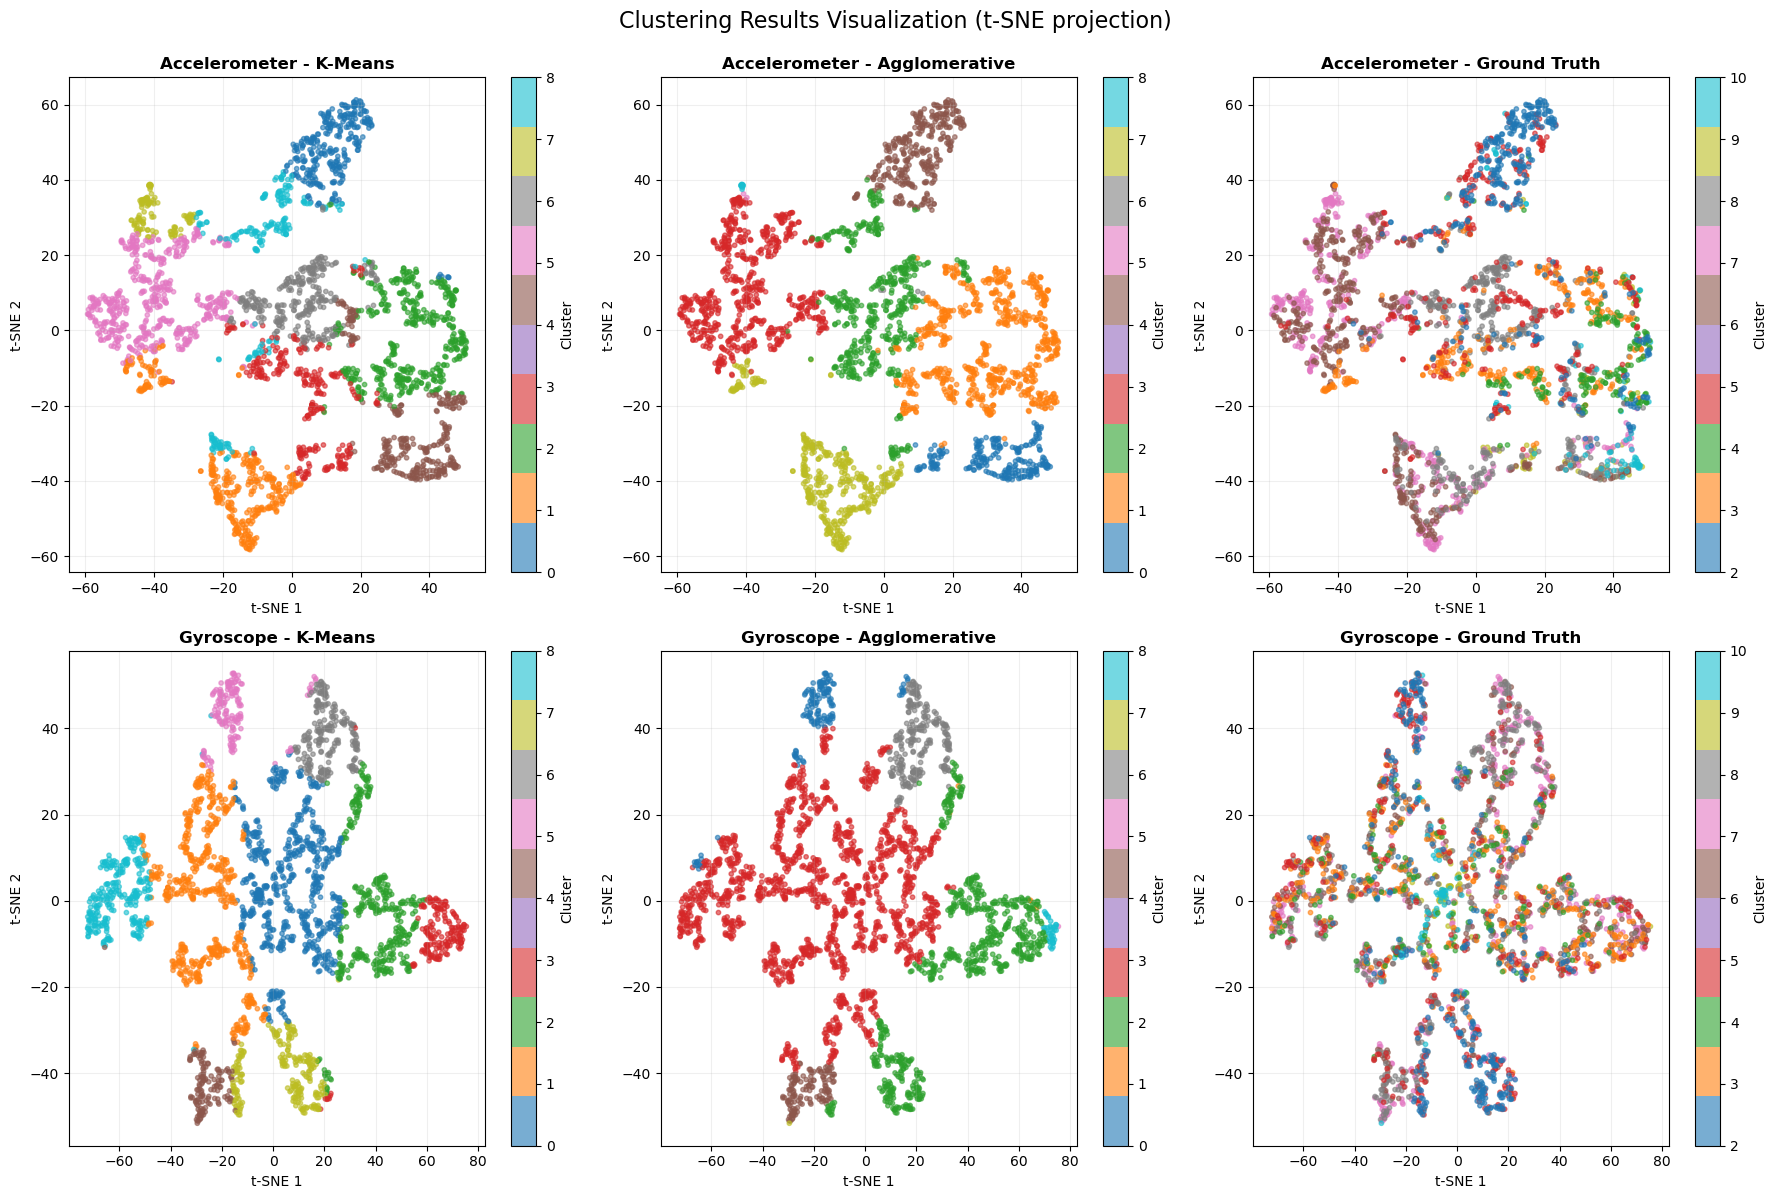

Visualization complete!


In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Reduce dimensions for visualization
print("Reducing embeddings to 2D using t-SNE...")
tsne_acc = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_gyro = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)

acc_tsne = tsne_acc.fit_transform(acc_emb_pca)
gyro_tsne = tsne_gyro.fit_transform(gyro_emb_pca)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Clustering Results Visualization (t-SNE projection)', fontsize=16, y=0.995)

palette = cm.tab10

# Row 1: Accelerometer
# K-Means
axes[0, 0].scatter(acc_tsne[:, 0], acc_tsne[:, 1], c=labels_kmeans_acc, cmap=palette, alpha=0.6, s=10)
axes[0, 0].set_title('Accelerometer - K-Means', fontweight='bold')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
axes[0, 0].grid(alpha=0.2)

# Agglomerative
axes[0, 1].scatter(acc_tsne[:, 0], acc_tsne[:, 1], c=labels_agg_acc, cmap=palette, alpha=0.6, s=10)
axes[0, 1].set_title('Accelerometer - Agglomerative', fontweight='bold')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
axes[0, 1].grid(alpha=0.2)

# Ground Truth
axes[0, 2].scatter(acc_tsne[:, 0], acc_tsne[:, 1], c=acc_gt, cmap=palette, alpha=0.6, s=10)
axes[0, 2].set_title('Accelerometer - Ground Truth', fontweight='bold')
axes[0, 2].set_xlabel('t-SNE 1')
axes[0, 2].set_ylabel('t-SNE 2')
axes[0, 2].grid(alpha=0.2)

# Row 2: Gyroscope
# K-Means
axes[1, 0].scatter(gyro_tsne[:, 0], gyro_tsne[:, 1], c=labels_kmeans_gyro, cmap=palette, alpha=0.6, s=10)
axes[1, 0].set_title('Gyroscope - K-Means', fontweight='bold')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
axes[1, 0].grid(alpha=0.2)

# Agglomerative
axes[1, 1].scatter(gyro_tsne[:, 0], gyro_tsne[:, 1], c=labels_agg_gyro, cmap=palette, alpha=0.6, s=10)
axes[1, 1].set_title('Gyroscope - Agglomerative', fontweight='bold')
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].grid(alpha=0.2)

# Ground Truth
axes[1, 2].scatter(gyro_tsne[:, 0], gyro_tsne[:, 1], c=gyro_gt, cmap=palette, alpha=0.6, s=10)
axes[1, 2].set_title('Gyroscope - Ground Truth', fontweight='bold')
axes[1, 2].set_xlabel('t-SNE 1')
axes[1, 2].set_ylabel('t-SNE 2')
axes[1, 2].grid(alpha=0.2)


# Create a colorbar legend showing cluster-to-color mapping
fig.colorbar(axes[0, 0].collections[0], ax=axes[0, 0], label='Cluster')
fig.colorbar(axes[0, 1].collections[0], ax=axes[0, 1], label='Cluster')
fig.colorbar(axes[0, 2].collections[0], ax=axes[0, 2], label='Cluster')
fig.colorbar(axes[1, 0].collections[0], ax=axes[1, 0], label='Cluster')
fig.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Cluster')
fig.colorbar(axes[1, 2].collections[0], ax=axes[1, 2], label='Cluster')

plt.tight_layout()
plt.show()

print("Visualization complete!")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go

# ── 1. Flatten & convert embeddings ──────────────────────────────────────────
def flatten_embeddings(feature_embeddings):
    """Flatten list of dicts, handling nested dict values."""
    records = []
    for d in feature_embeddings:
        row = {}
        for k, v in d.items():
            if isinstance(v, dict):
                for sub_k, sub_v in v.items():
                    row[f"{k}_{sub_k}"] = sub_v
            else:
                row[k] = v
        records.append(row)
    return pd.DataFrame(records).values.astype(np.float64)

acc_emb_array  = flatten_embeddings(acc_feature_embeddings)
gyro_emb_array = flatten_embeddings(gyro_feature_embeddings)

print(f"Acc shape:  {acc_emb_array.shape}")
print(f"Gyro shape: {gyro_emb_array.shape}")

# ── 2. t-SNE → 3D ────────────────────────────────────────────────────────────
acc_tsne_3d  = TSNE(n_components=3, random_state=42, perplexity=30, max_iter=1000).fit_transform(acc_emb_array)
gyro_tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30, max_iter=1000).fit_transform(gyro_emb_array)

print("t-SNE done.")

# ── 3. Color palette & plot helper ───────────────────────────────────────────
COLORS = [
    '#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261',
    '#8338ec', '#06d6a0', '#fb8500', '#3a86ff', '#ff006e'
]

def make_3d_scatter(coords, labels, title):
    unique_labels = sorted(set(labels))
    traces = []
    for lbl in unique_labels:
        mask = np.array(labels) == lbl
        name  = "Noise" if lbl == -1 else f"Cluster {lbl}"
        color = '#aaaaaa' if lbl == -1 else COLORS[lbl % len(COLORS)]
        traces.append(go.Scatter3d(
            x=coords[mask, 0], y=coords[mask, 1], z=coords[mask, 2],
            mode='markers',
            name=name,
            marker=dict(size=4, color=color, opacity=0.75),
        ))
    fig = go.Figure(traces)
    fig.update_layout(
        title=dict(text=title, font=dict(size=14)),
        scene=dict(
            xaxis_title="t-SNE 1", yaxis_title="t-SNE 2", zaxis_title="t-SNE 3",
            bgcolor='rgb(15,15,25)',
            xaxis=dict(backgroundcolor='rgb(15,15,25)', gridcolor='rgba(255,255,255,0.1)'),
            yaxis=dict(backgroundcolor='rgb(15,15,25)', gridcolor='rgba(255,255,255,0.1)'),
            zaxis=dict(backgroundcolor='rgb(15,15,25)', gridcolor='rgba(255,255,255,0.1)'),
        ),
        paper_bgcolor='rgb(15,15,25)',
        font=dict(color='white'),
        legend=dict(bgcolor='rgba(255,255,255,0.05)', bordercolor='rgba(255,255,255,0.1)', borderwidth=1),
        margin=dict(l=0, r=0, t=40, b=0),
        height=500,
    )
    return fig

# ── 4. Plot all methods × both sensors ───────────────────────────────────────
configs = [
    (acc_tsne_3d,  labels_kmeans_acc,  "K-Means — Accelerometer"),
    (gyro_tsne_3d, labels_kmeans_gyro, "K-Means — Gyroscope"),
    (acc_tsne_3d,  labels_agg_acc,     "Agglomerative — Accelerometer"),
    (gyro_tsne_3d, labels_agg_gyro,    "Agglomerative — Gyroscope"),
    (acc_tsne_3d,  labels_dbscan_acc,  "DBSCAN — Accelerometer"),
    (gyro_tsne_3d, labels_dbscan_gyro, "DBSCAN — Gyroscope"),
]

for coords, labels, title in configs:
    make_3d_scatter(coords, labels, title).show()

Reducing embeddings to 3D using t-SNE...


TypeError: float() argument must be a string or a real number, not 'dict'